In [2]:
import pandas as pd
from glob import glob


results_list = glob("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/results/*.csv")
len(results_list)

97

In [3]:
results_df_list = []
for result in results_list:
    df = pd.read_csv(result, index_col=0)
    results_df_list.append(df)

In [4]:
AB_pair = results_df_list[0][["A", "B"]]
AB_pair

,A,B
164,IgG plasma cell,macrophage
172,IgG plasma cell,neutrophil
175,IgG plasma cell,plasmacytoid dendritic cell
628,macrophage,neutrophil
715,neutrophil,plasmacytoid dendritic cell
...,...,...
425,conventional dendritic cell,macrophage
691,myeloid dendritic cell,plasmacytoid dendritic cell
625,macrophage,myeloid dendritic cell
154,IgG plasma cell,conventional dendritic cell


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_distribution(observations, save_path):
    A = observations

    # Set the plot style and context for scientific paper
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.5)

    # Sample data: replace this with your list A containing 100 observations
    # A = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] * 10

    # Calculate mean
    mean_val = np.mean(A)

    # Create a larger figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the distribution curve
    sns.distplot(A, hist=False, kde=True, kde_kws={'linewidth': 2.5}, ax=ax)

    # Customize the plot
    ax.set_title('Distribution of R_val for cellA with cellB')
    ax.set_xlabel('R_val')
    ax.set_ylabel('Density')

    # Add a dashed vertical line at the mean value with a custom darker blue color
    ax.axvline(mean_val, linestyle='--', color=(0.3, 0.6, 1), label=f'Mean: {mean_val:.2f}')
    ax.legend()

    # Set a tight layout
    plt.tight_layout()

    # Save the plot as a high-quality image
    plt.savefig(save_path)

/tmp/ipykernel_2729574/3762949506.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(A, hist=False, kde=True, kde_kws={'linewidth': 2.5}, ax=ax)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

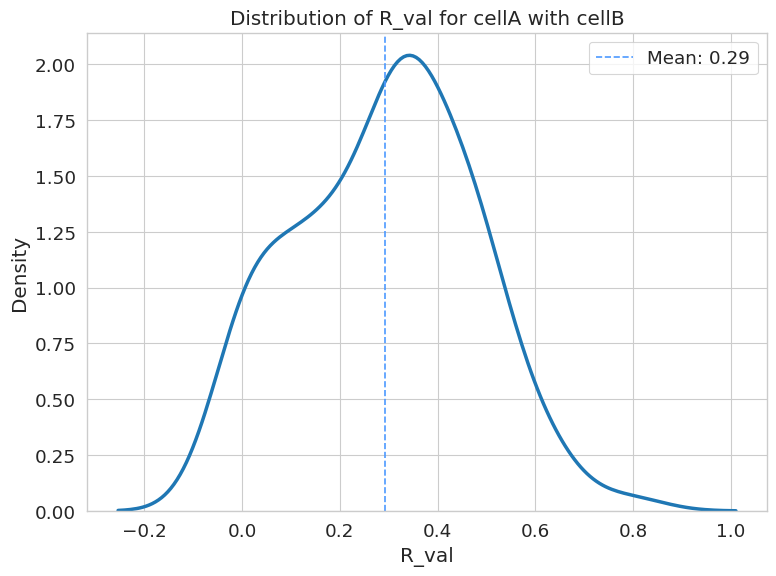

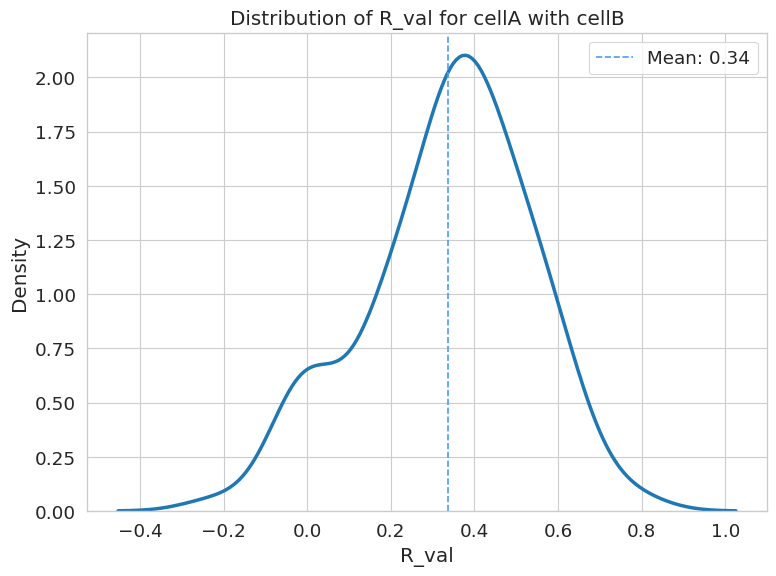

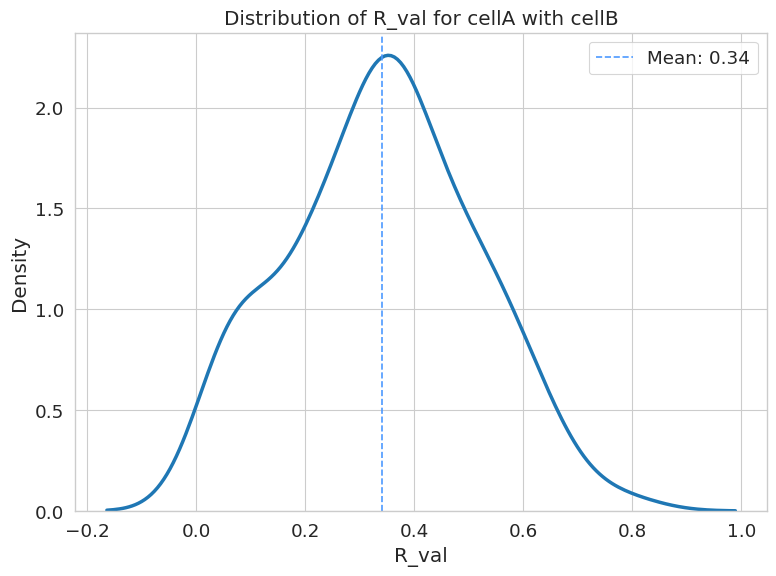

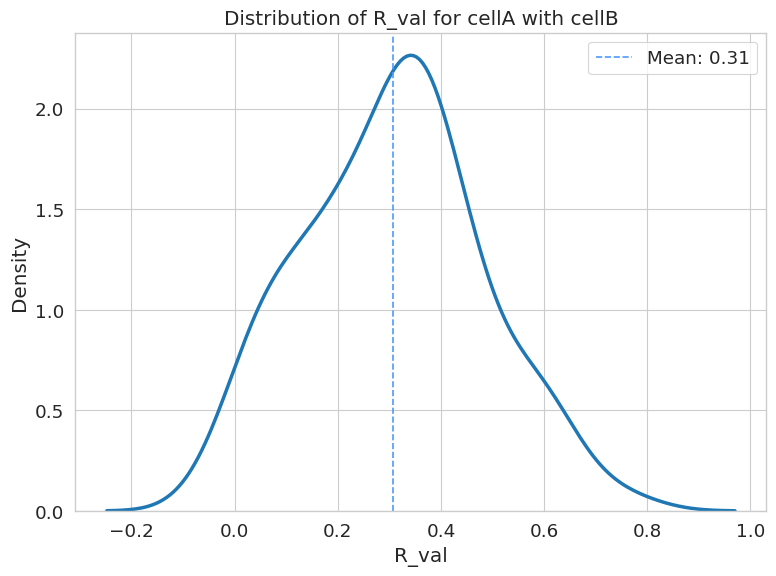

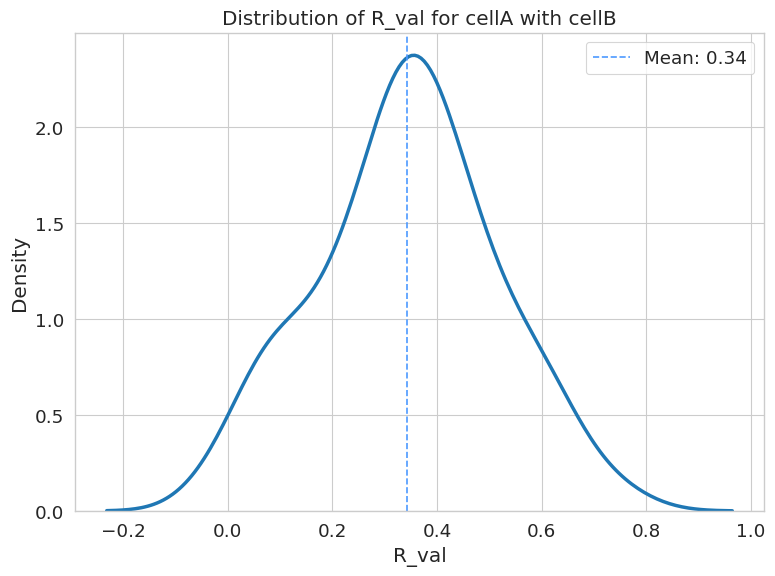

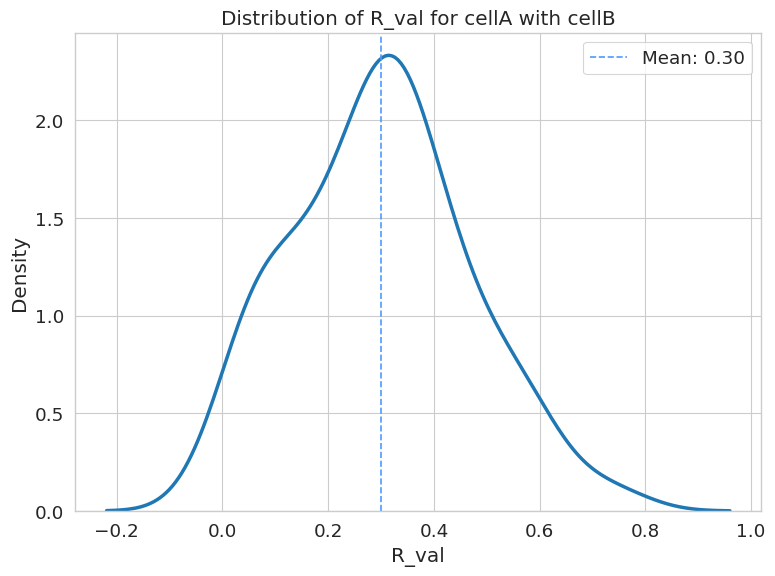

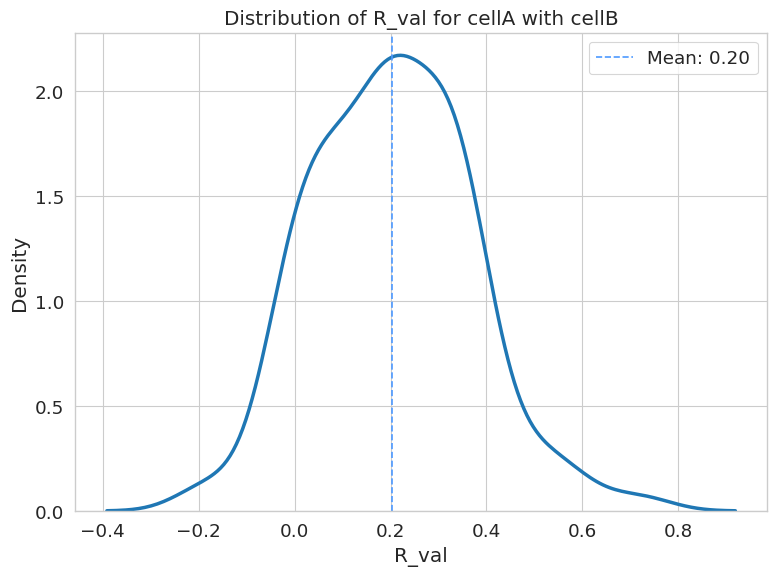

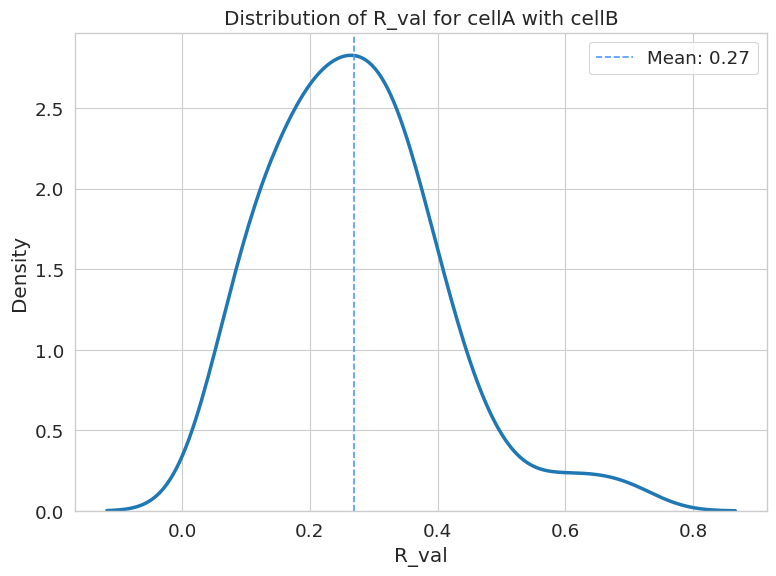

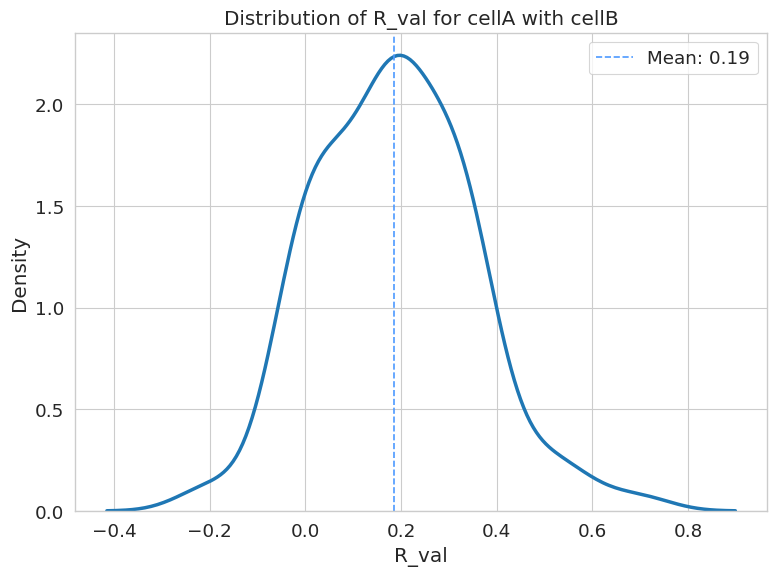

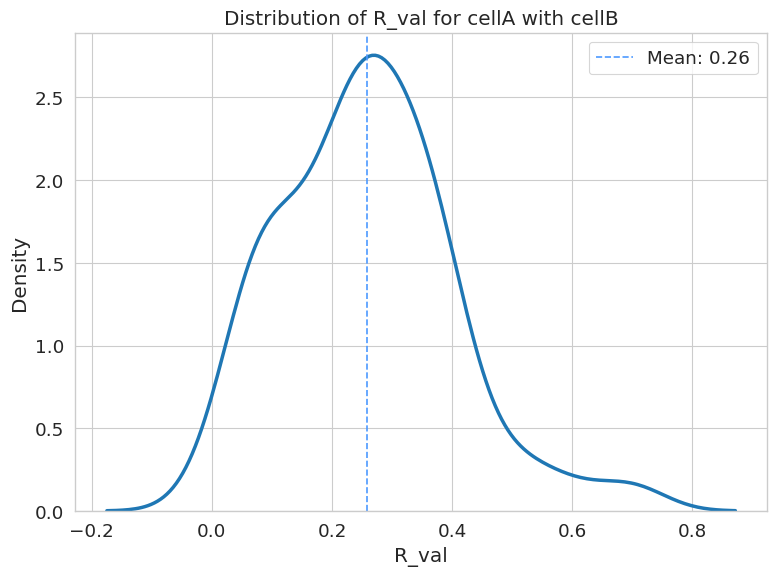

In [6]:
import os
import numpy as np


for row in AB_pair.iterrows():
    A = row[1]["A"]
    B = row[1]["B"]
    score_list = []
    for df in results_df_list:
        score = df[(df["A"]==A)&(df["B"]==B)]["R_val"].values[0]
        score_list.append(score)
    
    average_score = np.mean(score_list)
    save_path = os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/distribution_plots", f"{average_score:.3f}"+"_"+A+"_"+B+".png")
    
    plot_distribution(observations=score_list, save_path=save_path)

In [5]:
results_df_list[0]

,A,B,R_val,R_z_score,R_p_val
164,IgG plasma cell,macrophage,0.792164,427.302769,0.0
172,IgG plasma cell,neutrophil,0.790334,426.315889,0.0
175,IgG plasma cell,plasmacytoid dendritic cell,0.785384,423.645683,0.0
628,macrophage,neutrophil,0.763466,411.822936,0.0
715,neutrophil,plasmacytoid dendritic cell,0.760425,410.182494,0.0
...,...,...,...,...,...
425,conventional dendritic cell,macrophage,-0.641440,-346.000392,1.0
691,myeloid dendritic cell,plasmacytoid dendritic cell,-0.643204,-346.952242,1.0
625,macrophage,myeloid dendritic cell,-0.650387,-350.826451,1.0
154,IgG plasma cell,conventional dendritic cell,-0.672194,-362.589429,1.0


In [6]:
# Concatenate the DataFrames in the list
concatenated_df = pd.concat(results_df_list, ignore_index=True)
concatenated_df

,A,B,R_val,R_z_score,R_p_val
0,IgG plasma cell,macrophage,0.792164,427.302769,0.0
1,IgG plasma cell,neutrophil,0.790334,426.315889,0.0
2,IgG plasma cell,plasmacytoid dendritic cell,0.785384,423.645683,0.0
3,macrophage,neutrophil,0.763466,411.822936,0.0
4,neutrophil,plasmacytoid dendritic cell,0.760425,410.182494,0.0
...,...,...,...,...,...
71872,"activated CD8-positive, alpha-beta T cell",mammary gland epithelial cell,-0.135936,-84.915892,1.0
71873,alternatively activated macrophage,mammary gland epithelial cell,-0.142443,-88.980629,1.0
71874,"effector memory CD4-positive, alpha-beta T cell",vascular associated smooth muscle cell,-0.150819,-94.213228,1.0
71875,IgA plasma cell,alternatively activated macrophage,-0.152707,-95.392564,1.0


In [9]:
# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
average_df

,A,B,R_val,R_z_score,R_p_val
715,neutrophil,plasmacytoid dendritic cell,0.343270,168.961597,2.061856e-02
175,IgG plasma cell,plasmacytoid dendritic cell,0.341451,168.043479,3.931816e-24
172,IgG plasma cell,neutrophil,0.336520,165.428466,7.219656e-02
111,IgA plasma cell,IgG plasma cell,0.313255,154.562749,2.122142e-02
628,macrophage,neutrophil,0.307205,152.529167,2.309178e-02
...,...,...,...,...,...
247,"activated CD8-positive, alpha-beta T cell",capillary endothelial cell,-0.096148,-52.491460,8.681172e-01
109,"CD8-positive, alpha-beta memory T cell",vascular associated smooth muscle cell,-0.096819,-50.125034,7.918842e-01
121,IgA plasma cell,"effector memory CD4-positive, alpha-beta T cell",-0.128520,-60.541353,8.348849e-01
450,"effector memory CD4-positive, alpha-beta T cell",mammary gland epithelial cell,-0.129479,-63.115331,8.954887e-01


In [12]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(20, 20))
row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage
plt.savefig("brca_overall_Hist2Cell_clustermap.png")
plt.close()